# 2. Gridworld — Adding *State* with Q-Learning

In notebook 1, every decision was the same — pull an arm, get a reward, repeat. There was no notion of *situation*. Almost no real business problem is that simple: the best price depends on how much inventory is left, the best staffing level depends on expected demand, the best offer depends on the customer. That "situation" is called **state**, and a decision problem with state is called a **Markov Decision Process (MDP)**.

## The MDP framework

| Concept | Meaning | Business analogy |
|---|---|---|
| **State (s)** | The current situation | Inventory level, time of day, customer segment |
| **Action (a)** | A choice available in that state | Reorder quantity, price, staffing level |
| **Reward (r)** | Feedback after taking the action | Profit, cost, service level |
| **Transition** | How the state changes after an action | Inventory decreases with sales, replenishes with orders |
| **Policy (π)** | A rule mapping state → action | "If inventory < 10, order 20 units" |
| **Discount factor (γ)** | How much we value future reward vs. immediate reward | A "patience" dial, 0 = short-termist, close to 1 = far-sighted |

The word "Markov" just means: **the current state contains everything you need to decide what to do next** — you don't need the entire history, just where you are right now. This is a modeling assumption, and a lot of real-world RL engineering is about choosing a state representation for which this assumption holds well enough.

We'll build up the machinery in two passes. First, the smallest possible stateful environment — a straight line with 5 states — so every number in the Q-learning update is small enough to reason about by hand, and the role of `γ` (discount factor) is easy to see directly. Then we scale the exact same code up to a 2D grid, which is a closer shape to the discretized-state business problems in the rest of this series.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
plt.rcParams['figure.figsize'] = (6, 6)

## The environment: a 1D line world

Five states in a row, numbered 0 to 4:

```
[ Coin ][ Empty ][ Start ][ Stone ][ Treasure ]
   0        1        2        3         4
 reward:  +1       0        0        -2        +5
```

- The agent starts at state 2 (`Start`) and can move `left` or `right`.
- Landing on the **Coin** (state 0, reward **+1**) or the **Treasure** (state 4, reward **+5**) ends the episode.
- Landing on **Stone** (state 3) costs **-2** but doesn't end the episode — you can still turn back.
- Every other move gives reward 0.

This is deliberately tiny: there's a nearby small prize (the coin, 2 steps left) and a bigger prize further away (the treasure, 2 steps right) with a penalty in between you and it. That tension is exactly what makes `γ` (the discount factor) visible: a short-sighted agent should grab the coin; a far-sighted agent should push through the stone to reach the treasure.

In [2]:
ACTIONS = ["left", "right"]
N_STATES = 5
START_STATE = 2
TERMINAL_STATES = [0, 4]   # episode ends on Coin or Treasure
REWARDS = {0: +1, 1: 0, 2: 0, 3: -2, 4: +5}   # reward for landing on this state

def step_1d(state, action):
    if action == "left":
        next_state = max(0, state - 1)
    else:
        next_state = min(N_STATES - 1, state + 1)
    reward = REWARDS[next_state]
    done = next_state in TERMINAL_STATES
    return next_state, reward, done

## Step 1 — The Q-table

In the bandit notebook, `Q(a)` was a single number per arm. Now the agent needs a value **per (state, action) pair**: "how good is it to go `right` when I'm at state 2 (`Start`)?" We store this as a table: `Q[state][action]`.

Initially the agent knows nothing, so we start all values at 0 and let experience fill them in. With only 5 states and 2 actions, we can print the whole table.

In [3]:
Q_1d = {s: {a: 0.0 for a in ACTIONS} for s in range(N_STATES)}
Q_1d

{0: {'left': 0.0, 'right': 0.0},
 1: {'left': 0.0, 'right': 0.0},
 2: {'left': 0.0, 'right': 0.0},
 3: {'left': 0.0, 'right': 0.0},
 4: {'left': 0.0, 'right': 0.0}}

## Step 2 — The Q-learning update rule

This is the single most important formula in tabular RL:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \Big[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \Big]$$

Read it like this: *"Update my estimate of how good action `a` is in state `s`, by nudging it toward the reward I just got, PLUS the best I could still do from wherever I ended up (`s'`), discounted by `γ`."*

This is the same "nudge toward the observed value" idea as notebook 1's bandit update — the only new piece is `γ · max Q(s', a')`, which lets reward **propagate backward** through the state space. Set `γ = 0` and the formula collapses back to "just chase the very next reward" — no lookahead at all. As `γ` grows, a state's value increasingly reflects rewards several steps away, not just the next one. The state next to a prize learns its value first, then the state before that learns from it, and so on, until value has "flowed" all the way back to the start. This bootstrapping — learning a value from your *own current estimate* of a future value — is the defining idea of Q-learning (and, more broadly, of "temporal difference" learning).

- `alpha` (learning rate): how much we trust each new observation.
- `gamma` (discount factor): how much future reward matters vs. immediate reward.
- We use **epsilon-greedy** for exploration, exactly like notebook 1: mostly exploit the best known action, occasionally try a random one.

In [ ]:
ALPHA = 0.1
EPSILON = 0.2       # 20% chance of exploring a random action instead of exploiting the best known one
N_EPISODES = 500
MAX_STEPS_PER_EPISODE = 100   # safety cap in case the agent bounces around forever

def train_1d(gamma, n_episodes=N_EPISODES, seed=0):
    local_rng = np.random.default_rng(seed)
    Q = {s: {a: 0.0 for a in ACTIONS} for s in range(N_STATES)}
    for episode in range(n_episodes):
        state = START_STATE
        for t in range(MAX_STEPS_PER_EPISODE):
            # normally we should include a policy parameter to choose between "learn" and "greedy" policies, 
            # but for simplicity we will always use the "learn" policy here.
            # where learn policy means we use epsilon-greedy exploration to learn the Q-values, 
            # and greedy policy means we always take the action with the highest Q-value (no exploration).
            if local_rng.random() < EPSILON: # explore
                action = local_rng.choice(ACTIONS)
            else: # exploit
                best_value = max(Q[state].values())
                best_actions = [a for a, v in Q[state].items() if v == best_value]
                action = local_rng.choice(best_actions)

            next_state, reward, done = step_1d(state, action)
            max_future_q = max(Q[next_state].values())
            Q[state][action] += ALPHA * (reward + gamma * max_future_q - Q[state][action])

            state = next_state
            if done:
                break
    return Q

def print_q_table(Q, title):
    print(title)
    state_labels = {0: "Coin (+1)", 1: "Empty (0)", 2: "Start (0)", 3: "Stone (-2)", 4: "Treasure (+5)"}
    for s in range(N_STATES):
        print(f"  state {s} {state_labels[s]:<14} left: {Q[s]['left']:6.3f}   right: {Q[s]['right']:6.3f}")

## Step 3 — See `γ` change the policy, with nothing else different

We train the *same* agent on the *same* environment three times, changing only `γ`, and look at the learned value of `left` vs. `right` from the `Start` state.

In [5]:
for gamma in [0.0, 0.2, 0.6]:
    Q_1d = train_1d(gamma)
    print_q_table(Q_1d, f"gamma = {gamma}")
    print()

gamma = 0.0
  state 0 Coin (+1)      left:  0.000   right:  0.000
  state 1 Empty (0)      left:  1.000   right:  0.000
  state 2 Start (0)      left:  0.000   right: -1.995
  state 3 Stone (-2)     left:  0.000   right:  4.981
  state 4 Treasure (+5)  left:  0.000   right:  0.000

gamma = 0.2
  state 0 Coin (+1)      left:  0.000   right:  0.000
  state 1 Empty (0)      left:  1.000   right:  0.040
  state 2 Start (0)      left:  0.200   right: -1.018
  state 3 Stone (-2)     left:  0.006   right:  4.981
  state 4 Treasure (+5)  left:  0.000   right:  0.000

gamma = 0.6
  state 0 Coin (+1)      left:  0.000   right:  0.000
  state 1 Empty (0)      left:  1.000   right:  0.478
  state 2 Start (0)      left:  0.600   right:  1.000
  state 3 Stone (-2)     left:  0.565   right:  5.000
  state 4 Treasure (+5)  left:  0.000   right:  0.000



Read the `Start` row (state 2) across the three tables:

- **`γ = 0`** — the agent is completely myopic: `Q(s, a)` only ever reflects the *very next* reward, never anything further out. From `Start`, going `left` lands on `Empty` (reward 0) and going `right` lands on `Stone` (reward -2) — so `left` wins, but only because it dodges an immediate penalty, not because the agent "knows" the coin is out there. It has no way to see two steps ahead yet. 
- **`γ = 0.2`** — a little bit of future value starts leaking backward. `right`'s value is still negative (the stone still hurts), but less negative than before, because a sliver of the treasure's eventual +5 now discounts back into it. `left` is still preferred.
- **`γ = 0.6`** — enough future reward now propagates back through the stone that `right`'s value (≈1.0) overtakes `left`'s (≈0.6): the agent has learned it's worth eating the -2 at the stone to reach the +5 treasure two steps later. **The optimal policy flips from `left` to `right` purely because we changed how much the agent discounts the future — nothing about the environment changed.**

This is exactly the tradeoff `γ` controls in every later notebook: a high `γ` makes the agent hold out for a better price later (notebook 3), stock up now to avoid a stockout down the line (notebook 4), or accept short-term staffing cost to prevent a backlog spiral (notebook 6).

## Step 4 — Scaling up: a 2D Gridworld

The 1D line world made `γ` easy to isolate, but it's a bit *too* simple to look like a real business state space. Let's scale the same exact algorithm up to two dimensions — a grid the agent walks around in:

```
. . . .
. # . .
. . # G
S . . .
```
- `S` = start, `G` = goal (+10 reward), `#` = a penalty cell (-10 reward, acts like a hazard), `.` = a normal step (-1 reward, to encourage the shortest path).
- Actions: up / down / left / right.
- Episode ends when the agent reaches the goal or a hazard.

Nothing about the Q-learning update changes — only the shape of the state (a grid coordinate instead of a single number) and the environment's `step` function.

In [6]:
grid_layout = [
    ".  .  .  . ",
    ".  #  .  . ",
    ".  .  #  G ",
    "S  .  .  . ",
]
grid_layout = [row.split() for row in grid_layout]
N_ROWS, N_COLS = len(grid_layout), len(grid_layout[0])

START = next((r, c) for r in range(N_ROWS) for c in range(N_COLS) if grid_layout[r][c] == "S")
GOAL = next((r, c) for r in range(N_ROWS) for c in range(N_COLS) if grid_layout[r][c] == "G")
HAZARDS = {(r, c) for r in range(N_ROWS) for c in range(N_COLS) if grid_layout[r][c] == "#"}

ACTIONS = ["up", "down", "left", "right"]
ACTION_DELTA = {"up": (-1, 0), "down": (1, 0), "left": (0, -1), "right": (0, 1)}

def step(state, action):
    r, c = state
    dr, dc = ACTION_DELTA[action]
    nr, nc = r + dr, c + dc
    if not (0 <= nr < N_ROWS and 0 <= nc < N_COLS):
        nr, nc = r, c  # bump into wall -> stay put
    next_state = (nr, nc)
    if next_state == GOAL:
        return next_state, 10.0, True
    if next_state in HAZARDS:
        return next_state, -10.0, True
    return next_state, -1.0, False

print(f"Grid is {N_ROWS}x{N_COLS}. Start={START}, Goal={GOAL}, Hazards={HAZARDS}")

Grid is 4x4. Start=(3, 0), Goal=(2, 3), Hazards={(1, 1), (2, 2)}


Same idea as `Q_1d`, just keyed by `(row, col)` instead of a single integer.

In [7]:
Q = {(r, c): {a: 0.0 for a in ACTIONS} for r in range(N_ROWS) for c in range(N_COLS)}

In [ ]:
ALPHA = 0.1
GAMMA = 0.95
EPSILON = 0.2
N_EPISODES = 600
MAX_STEPS_PER_EPISODE = 100

def choose_action(state, epsilon):
    # again we are using epsilon-greedy exploration to learn the Q-values,
    # but normally, after exploration, we would switch to a greedy policy to exploit the learned Q-values.
    if rng.random() < epsilon: # explore
        return rng.choice(ACTIONS)
    q_values = Q[state]
    best_value = max(q_values.values())
    best_actions = [a for a, v in q_values.items() if v == best_value]
    return rng.choice(best_actions) # exploit

episode_rewards = []
episode_lengths = []

for episode in range(N_EPISODES):
    state = START
    total_reward = 0.0
    for t in range(MAX_STEPS_PER_EPISODE):
        action = choose_action(state, EPSILON)
        next_state, reward, done = step(state, action)

        best_next_value = max(Q[next_state].values())
        td_target = reward + GAMMA * best_next_value
        Q[state][action] += ALPHA * (td_target - Q[state][action])

        state = next_state
        total_reward += reward
        if done:
            break
    episode_rewards.append(total_reward)
    episode_lengths.append(t + 1)

print("Training done.")
print(f"Average reward, first 20 episodes: {np.mean(episode_rewards[:20]):.2f}")
print(f"Average reward, last 20 episodes:  {np.mean(episode_rewards[-20:]):.2f}")

Training done.
Average reward, first 20 episodes: 0.60
Average reward, last 20 episodes:  5.55


In [24]:
import pandas as pd
pd.DataFrame(Q).T.round(2)

up  down  left  right
0 0  -0.69 -0.80 -0.69  -0.73
  1  -0.50 -1.00 -0.54  -0.52
  2  -0.20 -0.27 -0.33  -0.19
  3  -0.10 -0.19 -0.10  -0.10
1 0  -0.94 -0.05 -0.98  -3.44
  1   0.00  0.00  0.00   0.00
  2  -0.10 -1.00 -1.00  -0.10
  3  -0.10  1.00 -0.10  -0.10
2 0  -1.32  0.43 -0.83   4.39
  1  -7.18  5.72  1.12  -7.71
  2   0.00  0.00  0.00   0.00
  3   0.00  0.00  0.00   0.00
3 0   2.92  4.43  4.43   5.72
  1   4.42  5.72  4.43   7.07
  2 -10.00  7.06  5.71   8.50
  3  10.00  8.47  7.06   8.50

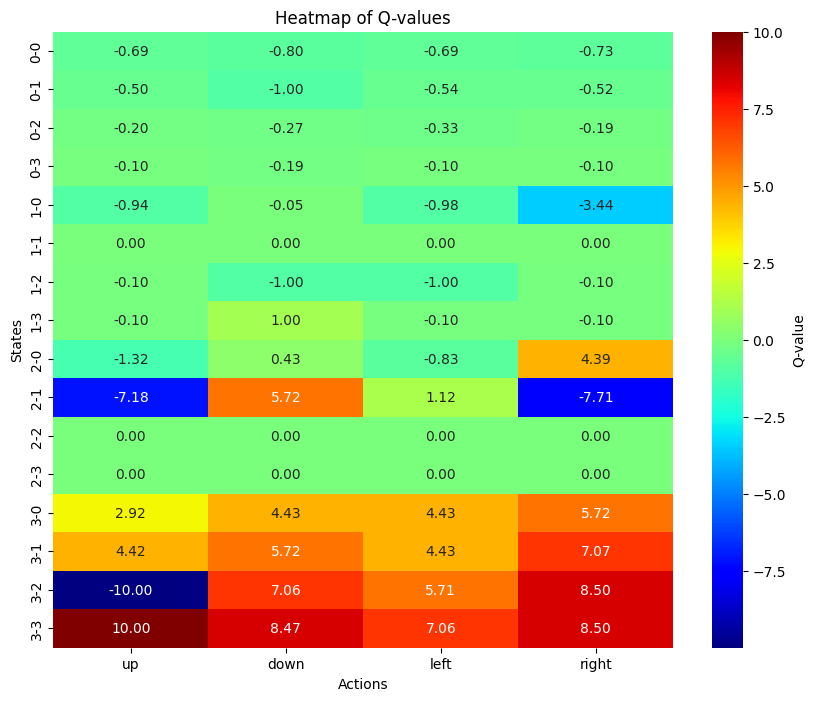

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(pd.DataFrame(Q).T, annot=True, fmt=".2f", cmap="jet", cbar_kws={'label': 'Q-value'})
plt.xlabel("Actions")
plt.ylabel("States")
plt.title("Heatmap of Q-values")
plt.show()

# we can see for example, when we are at (3, 3) the best action is to go "up" to reach the goal, 
# and when we are at (2, 1) the best action is to go "down" to avoid the hazard and go toward the shortest
# path to the goal.

## Step 5 — Did it learn? Plot the learning curve

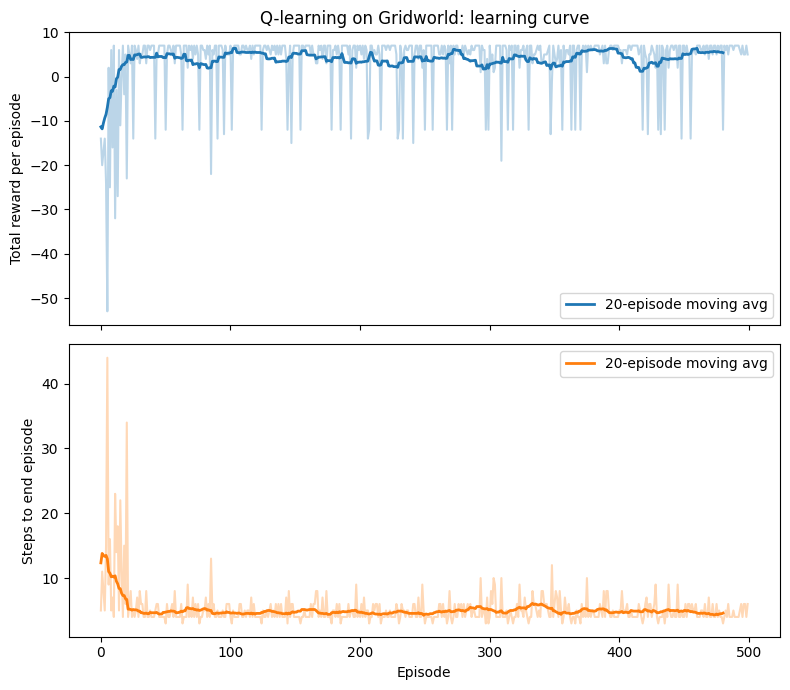

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
axes[0].plot(episode_rewards, alpha=0.3, color="tab:blue")
axes[0].plot(np.convolve(episode_rewards, np.ones(20)/20, mode="valid"), color="tab:blue", linewidth=2, label="20-episode moving avg")
axes[0].set_ylabel("Total reward per episode")
axes[0].legend()
axes[0].set_title("Q-learning on Gridworld: learning curve")

axes[1].plot(episode_lengths, alpha=0.3, color="tab:orange")
axes[1].plot(np.convolve(episode_lengths, np.ones(20)/20, mode="valid"), color="tab:orange", linewidth=2, label="20-episode moving avg")
axes[1].set_ylabel("Steps to end episode")
axes[1].set_xlabel("Episode")
axes[1].legend()
plt.tight_layout()
plt.show()

The reward per episode climbs and the number of steps needed drops — the agent is finding a shorter, safer route to the goal as training progresses, purely from trial and error, with no one ever telling it the shortest path.

## Step 6 — Visualize the learned policy

Once training is done, we generally stop exploring and just take the best known action in every state (`epsilon=0`) — this is the agent **exploiting** what it learned. Let's draw the policy as arrows.

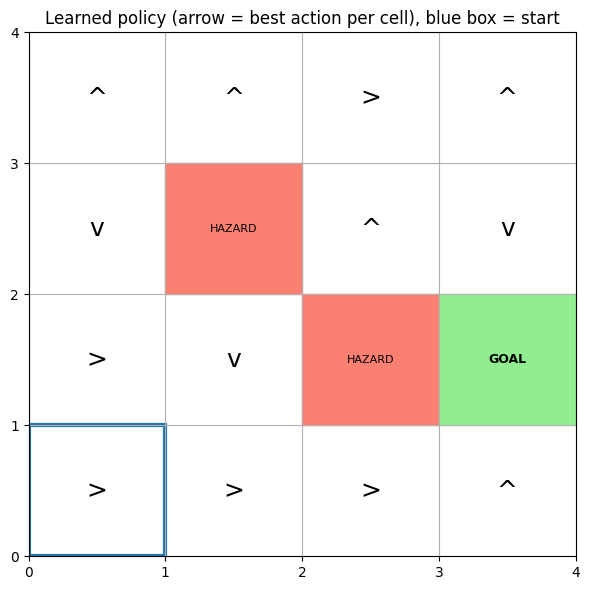

In [10]:
ARROW = {"up": "^", "down": "v", "left": "<", "right": ">"}

fig, ax = plt.subplots(figsize=(6, 6))
for r in range(N_ROWS):
    for c in range(N_COLS):
        if (r, c) in HAZARDS:
            ax.add_patch(plt.Rectangle((c, N_ROWS - 1 - r), 1, 1, color="salmon"))
            ax.text(c + 0.5, N_ROWS - 1 - r + 0.5, "HAZARD", ha="center", va="center", fontsize=8)
        elif (r, c) == GOAL:
            ax.add_patch(plt.Rectangle((c, N_ROWS - 1 - r), 1, 1, color="lightgreen"))
            ax.text(c + 0.5, N_ROWS - 1 - r + 0.5, "GOAL", ha="center", va="center", fontsize=9, fontweight="bold")
        else:
            best_action = max(Q[(r, c)], key=Q[(r, c)].get)
            ax.text(c + 0.5, N_ROWS - 1 - r + 0.5, ARROW[best_action], ha="center", va="center", fontsize=18)
            if (r, c) == START:
                ax.add_patch(plt.Rectangle((c, N_ROWS - 1 - r), 1, 1, fill=False, edgecolor="tab:blue", linewidth=3))

ax.set_xlim(0, N_COLS)
ax.set_ylim(0, N_ROWS)
ax.set_xticks(range(N_COLS + 1))
ax.set_yticks(range(N_ROWS + 1))
ax.grid(True)
ax.set_title("Learned policy (arrow = best action per cell), blue box = start")
plt.tight_layout()
plt.show()

The arrows should route the agent from `S` around the hazards toward `G` by the shortest safe path — a full policy, derived entirely from the Q-table, with no explicit pathfinding code.

## Key takeaways

1. Adding **state** turns a bandit problem into a full MDP — now the best action depends on *where you are*.
2. The **Q-table** generalizes the bandit's value estimates to one value per (state, action) pair — a single integer index in the line world, a `(row, col)` pair in the grid, and later a business quantity like inventory level or units-remaining-and-days-remaining.
3. The **Q-learning update** lets reward propagate backward through the state space via `γ · max Q(s', a')` — the agent learns multi-step consequences, not just immediate reward. We watched this directly in the 1D world: raising `γ` from 0 to 0.6 flipped the optimal first move from grabbing the nearby coin to pushing through to the distant treasure.
4. We still need exploration (epsilon-greedy) during training, but at deployment we typically exploit the learned policy (`epsilon=0`).
5. Once trained, the Q-table **is** the policy — no separate "planning" step needed to decide what to do in any state.

**Why this matters for business problems:** almost every operational decision problem — pricing, inventory, staffing — can be framed exactly like this: a discretized state, a handful of actions, a reward function you define based on business KPIs, and Q-learning finds a policy no one had to hand-write. The choice of `γ` is itself a business decision: how much should the policy sacrifice today for a payoff later? That's exactly what the remaining notebooks do, starting with dynamic pricing.